In [37]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

## Generate Data
---

$$ 

y_{true}=mx +b 

$$ 

$$ 

y=y_{true}+N(0,\sigma)

$$

---

In [38]:
true_slope = 5
true_intercept = 10
true_sigma = 1

num_points = 10

x_vals = np.linspace(0, 1, num_points)
true_y_vals = true_slope * x_vals + true_intercept
y_vals = true_y_vals + np.random.normal(scale=true_sigma, size=num_points)

true_params = {'slope': true_slope, 'intercept': true_intercept, 'sigma': true_sigma}

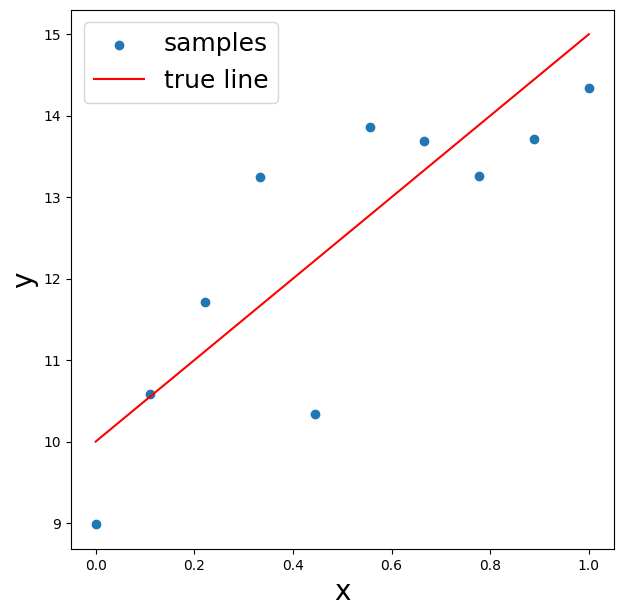

In [39]:
plt.figure(figsize=(7,7))
p1 = plt.scatter(x_vals, y_vals)
p2, = plt.plot(x_vals, true_y_vals, color='r')
plt.xlabel('x', fontsize=20)
plt.ylabel('y', fontsize=20)
plt.legend((p1, p2), ('samples', 'true line'), fontsize=18)

### Fit a Usual Linear Model

In [40]:
clf = LinearRegression()
clf.fit(x_vals.reshape(-1,1), y_vals)
preds = clf.predict(x_vals.reshape(-1,1))
resids = preds - y_vals

print('True Model:')
print('y_true = %s*x + %s'%(true_slope, true_intercept))
print('True sigma: %s\n'%true_params['sigma'])

print('Estimated Model:')
print('y_hat = %s*x + %s'%(clf.coef_[0], clf.intercept_))
print('Sd Residuals: %s'%(resids.std()))

mle_estimates = {'slope': clf.coef_[0], 'intercept': clf.intercept_, 'sigma': resids.std()}

True Model:
y_true = 5*x + 10
True sigma: 1

Estimated Model:
y_hat = 4.507214707720463*x + 10.119277211427875
Sd Residuals: 0.9845841934100292


### Bayesian Analysis with PyMC3
---
## Priors:

$$  m \sim \mathcal{N}(0, 20)  $$
$$  b\sim \mathcal{N}(0, 20)  $$
$$  \sigma \sim Exp(1) $$

---
## Likelihood:

$$  y|m,b,\sigma \sim \mathcal{N}(mx+b,\sigma)  $$

---

## Posterior:

$$  m,b,\sigma |y \sim ?  $$

$$  P (m,b,\sigma|y) \propto P (y|m,b,\sigma) * P(m) * P(b) * P(\sigma)   $$

---


In [ ]:
with pm.Model() as model:

    sigma = pm.Exponential("sigma", lam=1.0)
    intercept = pm.Normal("intercept", mu=0, sigma=20)
    slope = pm.Normal("slope", mu=0, sigma=20)

    likelihood = pm.Normal("y", mu=slope*x_vals + intercept, sigma=sigma, observed=y_vals)

    trace = pm.sample(1000, cores=4)

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.39        7            151.95 draws/s   0:00:13   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.53        7            137.12 draws/s   0:00:14   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.40        15           145.38 draws/s   0:00:13   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.43        7            127.56 draws/s   0:00:15   0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 25 seconds.


<Figure size 700x700 with 0 Axes>

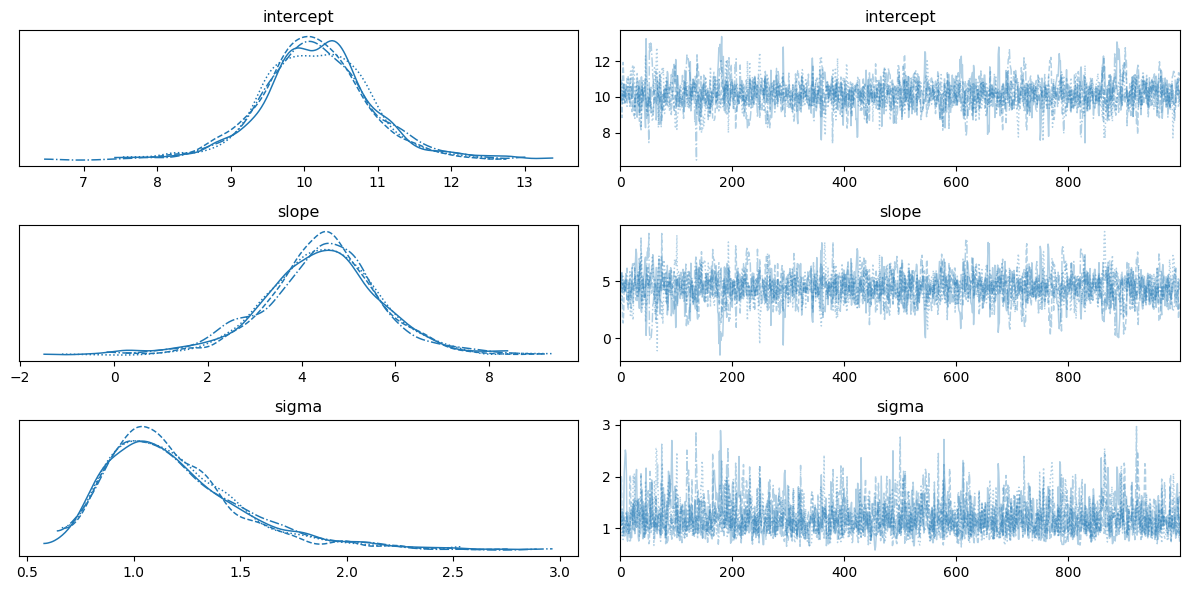

In [42]:
plt.figure(figsize=(7, 7))
az.plot_trace(trace)
plt.tight_layout()

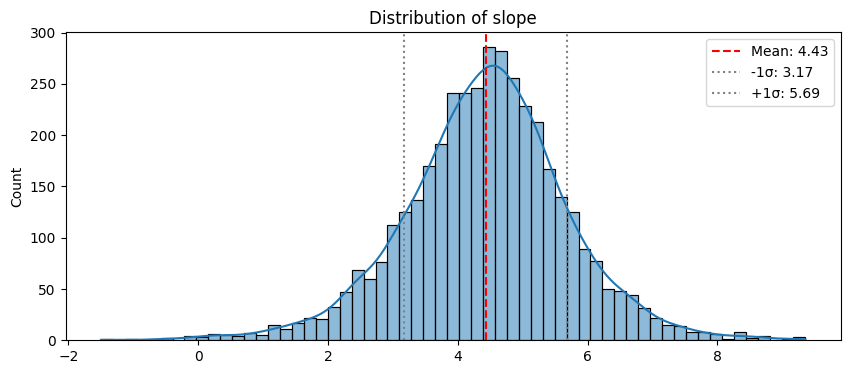

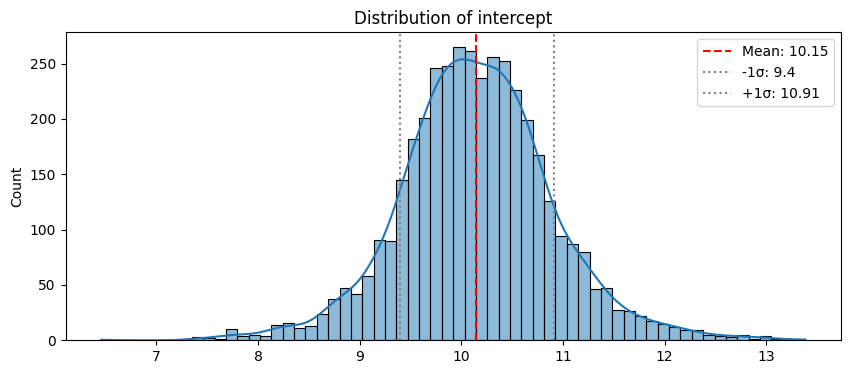

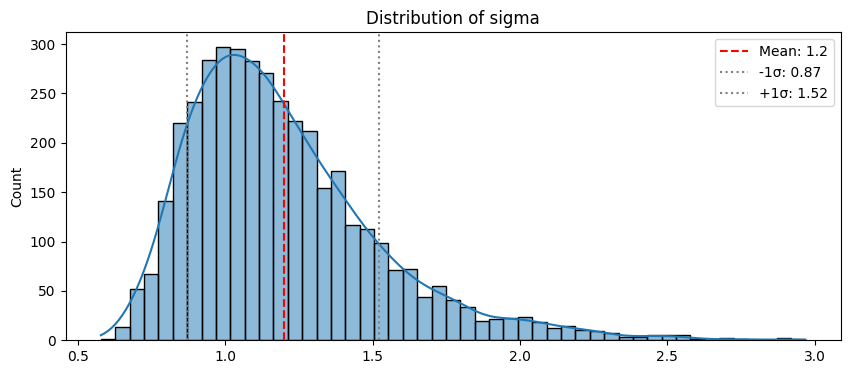

In [ ]:
for var in ['slope', 'intercept', 'sigma']:
    plt.figure(figsize=(10, 4))
    
    vals = trace.posterior[var].values.flatten()
    
    mean = round(vals.mean(), 2)
    lower = round(vals.mean() - vals.std(), 2)
    upper = round(vals.mean() + vals.std(), 2)
    
    sns.histplot(vals, kde=True)
    plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean}')
    plt.axvline(lower, color='gray', linestyle=':', label=f'-1σ: {lower}')
    plt.axvline(upper, color='gray', linestyle=':', label=f'+1σ: {upper}')
    plt.title(f'Distribution of {var}')
    plt.legend()
    plt.show